# LeetCode #208: Implement Trie (Prefix Tree)

https://leetcode.com/problems/implement-trie-prefix-tree/

## Comparison of Approaches
| Approach | Time (per op) | Space |
|---|---|---|
| Trie with HashMap Children ★ | O(L) | O(N×L×26) |
| Trie with Array Children | O(L) | O(N×L×26) |
| Sorted Array + Binary Search | O(L×log N) | O(N×L) |

## Understanding the Methods
### Trie with HashMap Children (Optimal)
Each node stores a map of child character to child node, plus a boolean indicating end-of-word. Insert walks the tree creating nodes as needed. Search walks the tree checking existence. StartsWith is like search but does not require the end-of-word flag. All operations take O(L) where L is the word length.

### Trie with Array Children
Same structure but uses a fixed-size array of 26 slots instead of a hash map. Slightly faster access but same asymptotic complexity.

### Sorted Array + Binary Search
Store all words in a sorted array. Search via binary search. StartsWith uses lower_bound. Simpler but slower for prefix queries on large datasets.

## Solutions

### C#

In [ ]:
public class Trie {
    private class TrieNode {
        public Dictionary<char, TrieNode> Children = new();
        public bool IsEnd;
    }

    private readonly TrieNode root = new();

    public void Insert(string word) {
        var node = root;
        foreach (char c in word) {
            if (!node.Children.ContainsKey(c))
                node.Children[c] = new TrieNode();
            node = node.Children[c];
        }
        node.IsEnd = true;
    }

    public bool Search(string word) {
        var node = FindNode(word);
        return node != null && node.IsEnd;
    }

    public bool StartsWith(string prefix) {
        return FindNode(prefix) != null;
    }

    private TrieNode FindNode(string s) {
        var node = root;
        foreach (char c in s) {
            if (!node.Children.ContainsKey(c)) return null;
            node = node.Children[c];
        }
        return node;
    }
}

### Python

In [ ]:
class TrieNode:
    def __init__(self):
        self.children: dict[str, 'TrieNode'] = {}
        self.is_end = False

class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word: str) -> None:
        node = self.root
        for c in word:
            if c not in node.children:
                node.children[c] = TrieNode()
            node = node.children[c]
        node.is_end = True

    def search(self, word: str) -> bool:
        node = self._find(word)
        return node is not None and node.is_end

    def startsWith(self, prefix: str) -> bool:
        return self._find(prefix) is not None

    def _find(self, s: str) -> TrieNode | None:
        node = self.root
        for c in s:
            if c not in node.children:
                return None
            node = node.children[c]
        return node

### Go

In [ ]:
type Trie struct {
    children [26]*Trie
    isEnd    bool
}

func Constructor() Trie {
    return Trie{}
}

func (t *Trie) Insert(word string) {
    node := t
    for _, c := range word {
        idx := c - 'a'
        if node.children[idx] == nil {
            node.children[idx] = &Trie{}
        }
        node = node.children[idx]
    }
    node.isEnd = true
}

func (t *Trie) Search(word string) bool {
    node := t.find(word)
    return node != nil && node.isEnd
}

func (t *Trie) StartsWith(prefix string) bool {
    return t.find(prefix) != nil
}

func (t *Trie) find(s string) *Trie {
    node := t
    for _, c := range s {
        idx := c - 'a'
        if node.children[idx] == nil {
            return nil
        }
        node = node.children[idx]
    }
    return node
}

### Rust

In [ ]:
use std::collections::HashMap;

struct Trie {
    children: HashMap<char, Trie>,
    is_end: bool,
}

impl Trie {
    fn new() -> Self {
        Trie { children: HashMap::new(), is_end: false }
    }

    fn insert(&mut self, word: String) {
        let mut node = self;
        for c in word.chars() {
            node = node.children.entry(c).or_insert_with(Trie::new);
        }
        node.is_end = true;
    }

    fn search(&self, word: String) -> bool {
        self.find(&word).map_or(false, |n| n.is_end)
    }

    fn starts_with(&self, prefix: String) -> bool {
        self.find(&prefix).is_some()
    }

    fn find(&self, s: &str) -> Option<&Trie> {
        let mut node = self;
        for c in s.chars() {
            match node.children.get(&c) {
                Some(next) => node = next,
                None => return None,
            }
        }
        Some(node)
    }
}

## Example Scenarios

1. **Common Case — Insert and Search:** `insert("apple")`, `insert("app")`, `search("apple")` → true, `search("app")` → true, `search("ap")` → false. Insert "apple" creates 5 nodes (a-p-p-l-e), marking 'e' as end-of-word. "app" reuses the existing a-p-p path and marks the second 'p' as end-of-word. "ap" exists as a path but 'p' is NOT marked as end. WHY tricky: The distinction between prefix existence and word existence is the core trie concept — the `isEnd` flag is essential.

2. **Slightly Complex — Overlapping Prefixes:** `insert("the")`, `insert("there")`, `insert("their")`, `insert("them")`, `startsWith("the")` → true. Four words share prefix "the". The trie branches at 'e': "there"/"their" via 'r', "them" via 'm'. Only 8 nodes for 4 words (17 total chars) — $47\%$ compression. WHY tricky: Shows how tries compress shared prefixes. `startsWith` differs from `search` only by not checking `isEnd`.

3. **Edge Case — Time Factor (Long Words):** `insert("a" * 2000)`, `search("a" * 2000)` → true, `search("a" * 1999 + "b")` → false. A word of length 2000 creates a chain of 2000 nodes. The near-miss search traverses 1999 nodes before failing at position 2000. WHY tricky: Worst-case $O(L)$ per operation where $L = 2000$. The fail-at-end case is the worst for search — maximum traversal before returning false.

4. **Edge Case — Space Factor (26-way Branching):** `insert("a"), insert("b"), ..., insert("z")` — 26 single-letter words. Root has 26 children (maximum fan-out). Array-based: each node allocates 26 pointers regardless; HashMap: only populated slots. WHY tricky: Maximum branching factor tests the space tradeoff between array ($O(N \times 26)$ per node) and HashMap ($O(N \times \text{avg\_children})$) implementations.

5. **Almost-Impossible — 30,000 Operations:** 30,000 mixed insert/search/startsWith on words of length up to 2000. Worst case: 30K inserts of unique 2000-char words $= 6 \times 10^7$ nodes ($\approx 2.4$GB). WHY tricky: The absolute worst case could exhaust memory. In practice, shared prefixes dramatically reduce node count. Interviewers often ask about this space bound: $O(N \times L)$ total.

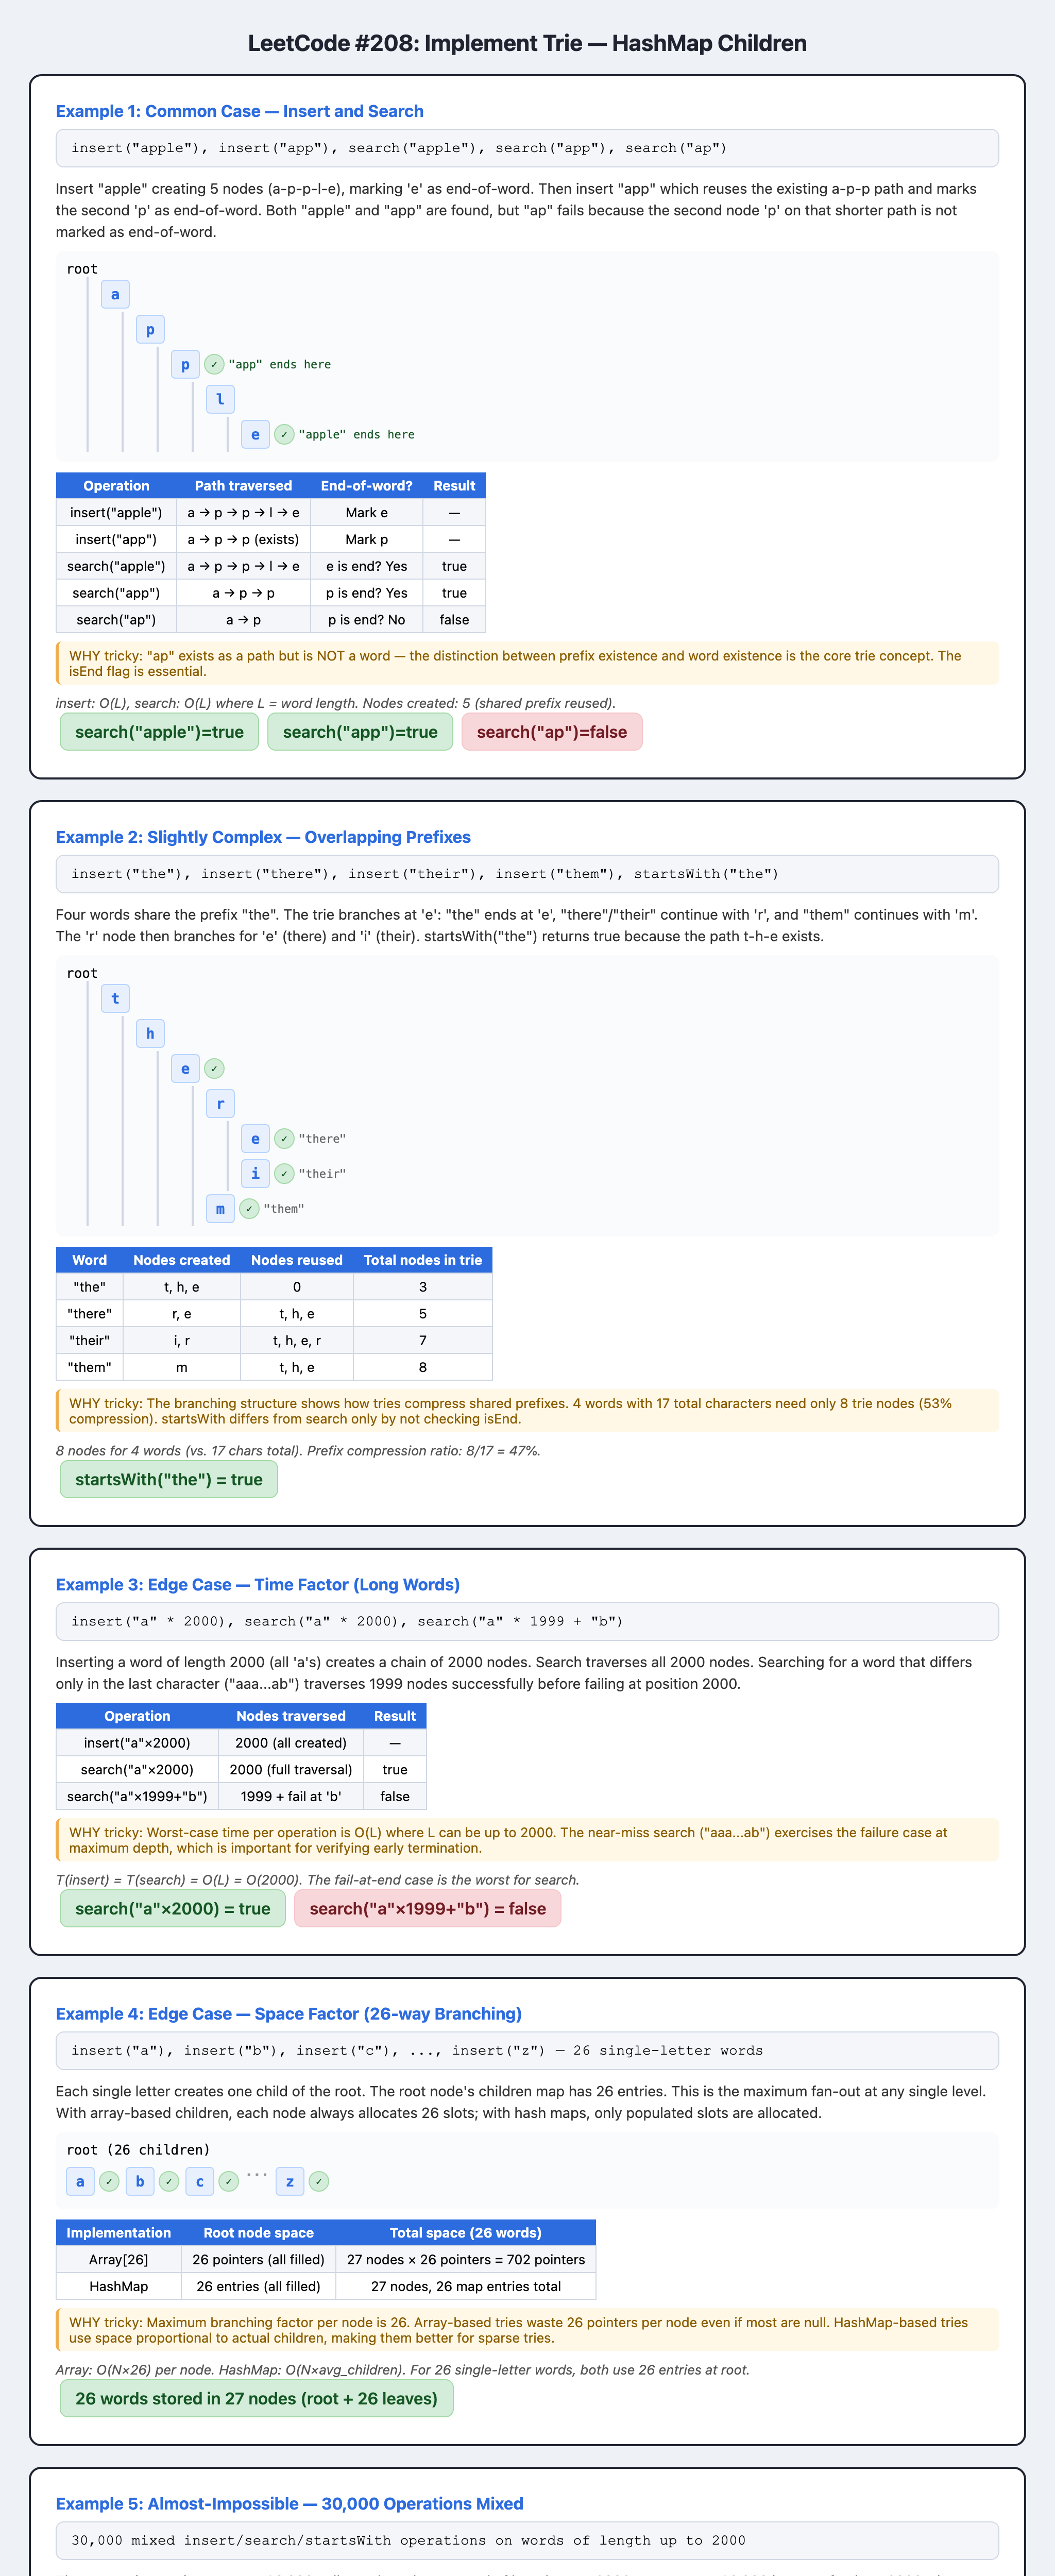